In [1]:
%run "02_data_pipeline.ipynb"


Training path: d:\Projects\Lipilens\MODI MATRA DATASET\MODI MATRA DATASET\Training
Testing path: d:\Projects\Lipilens\MODI MATRA DATASET\MODI MATRA DATASET\Testing
Training samples: 19320
Testing samples: 8280
Number of classes: 46
Training: 16422
Validation: 2898
Testing: 8280
DataLoaders ready.
Images: torch.Size([64, 1, 32, 32])
Labels: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64


In [2]:
# Import pytorch
import torch

# Neural network module
import torch.nn as nn

# Optimization algorithms
import torch.optim as optim 

# useful data loading utilities
from torch.utils.data import DataLoader

# Visualization
import matplotlib.pyplot as plt 


In [3]:
# Checking if CUDA is available or not 
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Device : ", device)

# GPU INFO 
if torch.cuda.is_available():
    print("GPU : " , torch.cuda.get_device_name(0))

Device :  cuda
GPU :  NVIDIA GeForce RTX 2050


Connecting notebook 02 to this
We need:

- `train_loader`
- `val_loader`
- `test_loader`

In [4]:
# Number of MODI Character Classes
NUM_CLASSES = 46
# Check that the DataLoaders from Notebook 02 exist
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

print("Number of classes:", NUM_CLASSES)


Training batches: 257
Validation batches: 46
Testing batches: 130
Number of classes: 46


Inspecting input

In [5]:
# get one batch from training dataloader
images, labels = next(iter(train_loader))


# display tensor shapes
print("Images : ", images.shape)
print("Labels : ", labels.shape)

# move batch to device
images = images.to(device)
labels = labels.to(device)

print("\n Images device : ", images.device)
print("Label Device : ", labels.device)


Images :  torch.Size([64, 1, 32, 32])
Labels :  torch.Size([64])

 Images device :  cuda:0
Label Device :  cuda:0


## Build of CNN
CNN learns visual patterns using convolution layers
Network will progresively transform layers
`32 × 32`
→ detect simple strokes

`16 × 16`
→ combine local patterns

`8 × 8`
→ learn more complex character structures

`4 × 4`
→ compact representation

Then the fully connected layers classify the character.

Architecture:

Input
`1 × 32 × 32`

↓

Conv2D: `1 → 32`

↓

ReLU

↓

MaxPool

↓

Conv2D: `32 → 64`

↓

ReLU

↓

MaxPool

↓

Conv2D: `64 → 128`

↓

ReLU

↓

MaxPool

↓

Flatten

↓

Fully Connected

↓

46 class outputs

In [6]:
class ModiCNN(nn.Module):
    def __init__(self, num_classes = 46):
        super().__init__()

        # Convolution Block 01
        # # ip -> 1 x 32 x 32
        # # op -> 32 x 32 x 32
        # Learns basic filters
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )  

        # Convolution Block 02
        # ip -> 32 x 16 x 16
        # op -> 64 x 16 x 16
        # this layer combine simpler features into meaningful strokes
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Convolution Block 03
        # ip -> 64 x 8 x 8
        # op -> 128 x 8 x 8 
        # Deeper features
        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        )



        # MaxPooling reduces spatial dimensions by 2
        self.pool = nn.MaxPool2d(kernel_size=2)
        # relu introduces non linearity
        self.relu = nn.ReLU()
        # ----------------------------------------------------
        # Fully Connected Layers
        # ----------------------------------------------------
        #
        # After three pooling operations:
        #
        # 32 × 32
        #   ↓ pool
        # 16 × 16
        #   ↓ pool
        # 8 × 8
        #   ↓ pool
        # 4 × 4
        #
        # Final feature map:
        #
        # 128 × 4 × 4 = 2048 values

        self.fc1 = nn.Linear(
            128 * 4 * 4,
            256
        )
        # Final classifier
        # 256 features → 46 Modi classes
        self.fc2 = nn.Linear(
            256, 
            num_classes
        )
    def forward(self, x):
        # 1st Convolution Block
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        # Second convolution block
        x = self.relu(self.conv2(x))
        x = self.pool(x)

        # Third convolution block
        x = self.relu(self.conv3(x))
        x = self.pool(x)

        # Flatten feature maps
        # [batch, 128, 4, 4]
        # becomes
        # [batch, 2048]

        x = torch.flatten(x , start_dim=1)

        # fully connected layer
        x = self.relu(self.fc1(x))

        # final class scores
        x = self.fc2(x)

        return x

    



## 6. Create the Model

We now instantiate the CNN and move it to the selected device.

The final layer contains 46 outputs because we have 46 Modi character classes.

The outputs are not probabilities yet.

They are called **logits**, which are raw class scores.

In [7]:
model = ModiCNN(
    num_classes=NUM_CLASSES
)

model = model.to(device)
print(model)

ModiCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=46, bias=True)
)


## 7. Count Trainable Parameters

Every trainable parameter is a value that the neural network can
adjust during training.

These parameters are what the model actually learns.

We count them to understand the size of our CNN.

In [8]:
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Trainable Parameters : {trainable_parameters}")

Trainable Parameters : 629038


## 8. Test the Forward Pass

Before training anything, we should verify that data can successfully
travel through the entire network.

Input:

`[64, 1, 32, 32]`

Expected output:

`[64, 46]`

Each row represents one image.

Each of the 46 values represents the model's score for one Modi class.

In [9]:
model.eval()

with torch.no_grad():
    outputs = model(images)

print("Input Shape : ", images.shape)
print("Output Shape : ", outputs.shape)

Input Shape :  torch.Size([64, 1, 32, 32])
Output Shape :  torch.Size([64, 46])


## 9. Understand the CNN Tensor Flow

For one image, the tensor moves through the network approximately like this:

`[1, 32, 32]`

↓

Conv2D

`[32, 32, 32]`

↓

MaxPool

`[32, 16, 16]`

↓

Conv2D

`[64, 16, 16]`

↓

MaxPool

`[64, 8, 8]`

↓

Conv2D

`[128, 8, 8]`

↓

MaxPool

`[128, 4, 4]`

↓

Flatten

`[2048]`

↓

Linear

`[256]`

↓

Linear

`[46]`

The spatial dimensions become smaller while the number of feature
channels becomes larger.

This allows the network to gradually transform raw pixels into
higher-level visual features.

## 10. Define the Loss Function

The CNN produces 46 scores for every image.

We need a way to measure how wrong those predictions are.

For this multi-class classification problem we use:

`CrossEntropyLoss`

It compares:

- The model's 46 output scores
- The correct class label

A lower loss means the predictions are becoming better aligned with
the correct classes.

In [10]:
# CrossEntropyLoss is appropriate for multi class classification

criterion = nn.CrossEntropyLoss()
print(criterion)

CrossEntropyLoss()


## 11. Define the Optimizer

The optimizer updates the CNN's trainable parameters based on the
gradients calculated during backpropagation.

We will use Adam for the baseline model.

Initial learning rate:

`0.001`

The training process will repeatedly perform:

Forward pass
→ Calculate loss
→ Backpropagation
→ Update weights

In [11]:
# Adam Optimizer

optimizer = optim.Adam(
    model.parameters(),
    lr = 0.001
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 12. Training Loop

Now we can finally train the CNN.

For each batch:

1. Get images and labels
2. Move them to the device
3. Clear previous gradients
4. Run the forward pass
5. Calculate the loss
6. Calculate gradients using backpropagation
7. Update the model parameters

This process repeats for every batch in every epoch.

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train() # training mode
    running_loss = 0.0 # track total loss
    correct = 0 # track correct prediction
    total = 0 # track total samples
    # loop through every batch
    for images, labels in loader:
        # Move data to GPU or CPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # forward pass 
        outputs = model(images)

        # calculate loss
        loss = criterion(outputs, labels)

        # backpropagation
        loss.backward()
        # update weights
        optimizer.step()
        # accumulate loss
        running_loss += loss.item() * images.size(0)
        # find predicted class 
        predictions = outputs.argmax(dim=1)
         # Count correct predictions
        correct += (
            predictions == labels
        ).sum().item()

        # Count samples
        total += labels.size(0)

    # Average loss across dataset
    epoch_loss = running_loss / total

    # Accuracy
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


## 13. Validation Loop

Validation is similar to training, but there is one critical difference:

We do **not** update the model's weights.

The model only makes predictions.

This tells us whether the model is generalizing beyond the training data.

In [13]:
# AI 
def validate(model, loader, criterion, device):

    # Put model into evaluation mode
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # Disable gradient calculation
    with torch.no_grad():

        for images, labels in loader:

            # Move data to device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(
                outputs,
                labels
            )

            # Accumulate loss
            running_loss += (
                loss.item() * images.size(0)
            )

            # Get predicted classes
            predictions = outputs.argmax(dim=1)

            # Count correct predictions
            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    # Average loss
    epoch_loss = running_loss / total

    # Accuracy
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

## 14. Train the CNN

We now combine the training and validation loops.

An **epoch** means the model has processed the entire training dataset once.

We will begin with 10 epochs.

This is our baseline experiment, not the final optimized model.

In [14]:
# Number of complete passes through the training dataset
EPOCHS = 10

# Store metrics for plotting later
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

for epoch in range(EPOCHS):

    # Train for one epoch
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Validate
    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Display progress
    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/10] | Train Loss: 3.2868 | Train Acc: 0.0854 | Val Loss: 2.8627 | Val Acc: 0.1618
Epoch [2/10] | Train Loss: 2.4570 | Train Acc: 0.2725 | Val Loss: 2.1246 | Val Acc: 0.3627
Epoch [3/10] | Train Loss: 1.8303 | Train Acc: 0.4432 | Val Loss: 1.7241 | Val Acc: 0.4714
Epoch [4/10] | Train Loss: 1.4419 | Train Acc: 0.5457 | Val Loss: 1.4661 | Val Acc: 0.5397
Epoch [5/10] | Train Loss: 1.1665 | Train Acc: 0.6299 | Val Loss: 1.2763 | Val Acc: 0.6039
Epoch [6/10] | Train Loss: 0.9502 | Train Acc: 0.6936 | Val Loss: 1.1531 | Val Acc: 0.6273
Epoch [7/10] | Train Loss: 0.7693 | Train Acc: 0.7499 | Val Loss: 1.0203 | Val Acc: 0.6687
Epoch [8/10] | Train Loss: 0.6311 | Train Acc: 0.7941 | Val Loss: 0.9744 | Val Acc: 0.7005
Epoch [9/10] | Train Loss: 0.5144 | Train Acc: 0.8272 | Val Loss: 0.9256 | Val Acc: 0.7150
Epoch [10/10] | Train Loss: 0.4233 | Train Acc: 0.8621 | Val Loss: 0.9399 | Val Acc: 0.7250


## 15. Plot Training Progress

We visualize training and validation performance across epochs.

Two things are particularly important:

### Loss

We generally want loss to decrease.

### Accuracy

We generally want accuracy to increase.

The relationship between training and validation curves can also
reveal overfitting.

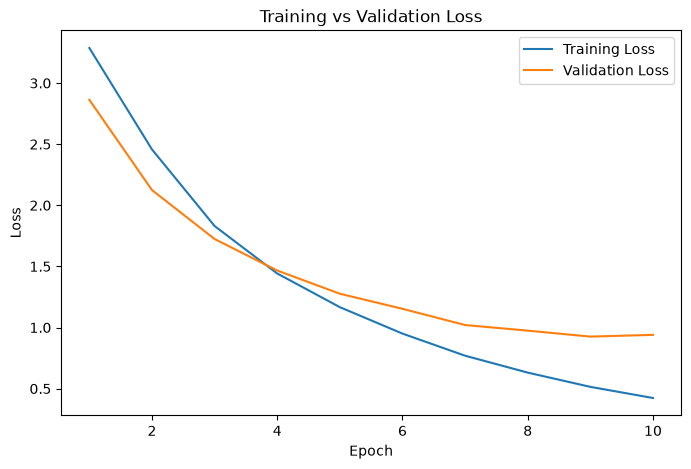

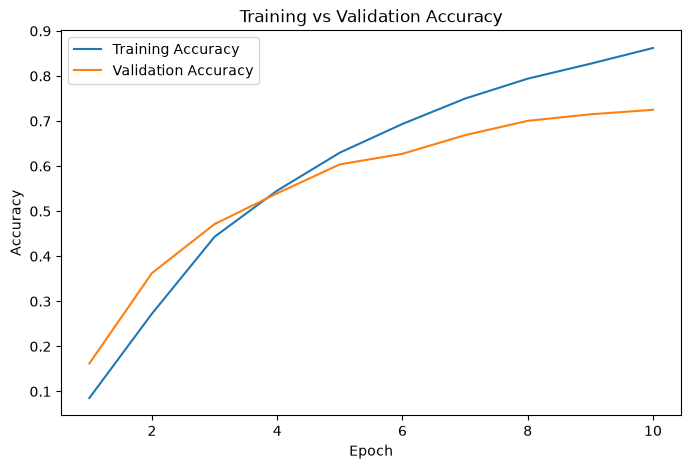

In [15]:
# Create epoch numbers for the x-axis
epochs = range(1, EPOCHS + 1)

# ------------------------------------------------------------
# Plot loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# ------------------------------------------------------------
# Plot accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

## 16. Evaluate on the Official Test Set

The model has now been trained and validated.

We can finally evaluate it on the official Testing dataset.

This is the first time we use the test set for model performance.

The test accuracy gives us our baseline estimate of how well the
CNN recognizes unseen Modi characters.

In [16]:
# Evaluate the trained model on the official test set

test_loss, test_accuracy = validate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4%}")

Test Loss: 4.7604
Test Accuracy: 32.1498%


## 17. Save the Trained Model

We save the trained model parameters so that we do not have to train
the CNN from scratch every time we want to use it.

The saved file contains the learned weights.

Later, LipiLens can load these weights and use the CNN for inference.

In [18]:
import os
import torch

# Path where the trained model will be saved
model_path = "../models/modi_cnn_v1.pth"

# Extract the parent directory path ('../models')
model_dir = os.path.dirname(model_path)

# Create the directory if it does not exist
if model_dir and not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save only the learned parameters
torch.save(
    model.state_dict(),
    model_path
)


## 18. Final Baseline

Our first CNN experiment is now complete.

Record the following results:

- Number of classes
- Number of training samples
- Number of validation samples
- Number of test samples
- Number of model parameters
- Number of epochs
- Final training accuracy
- Final validation accuracy
- Final test accuracy

This becomes the baseline against which future LipiLens models
can be compared.

We should improve the model only after understanding its errors.

In [19]:
# Print a compact summary of the experiment

print("=" * 50)
print("LIPILENS CNN V1 BASELINE")
print("=" * 50)

print("Classes           :", NUM_CLASSES)
print("Training samples  :", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples   :", len(test_dataset))
print("Parameters        :", f"{trainable_parameters:,}")
print("Epochs            :", EPOCHS)

print(
    "Final Train Acc   :",
    f"{train_accuracies[-1]:.4%}"
)

print(
    "Final Val Acc     :",
    f"{val_accuracies[-1]:.4%}"
)

print(
    "Test Acc          :",
    f"{test_accuracy:.4%}"
)

LIPILENS CNN V1 BASELINE
Classes           : 46
Training samples  : 16422
Validation samples: 2898
Testing samples   : 8280
Parameters        : 629,038
Epochs            : 10
Final Train Acc   : 86.2136%
Final Val Acc     : 72.4983%
Test Acc          : 32.1498%
